/home/bipar001/anaconda3/envs/wolfhusky/lib/python3.9/site-packages/sklearn/svm/_base.py:985: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/home/bipar001/anaconda3/envs/wolfhusky/lib/python3.9/site-packages/sklearn/svm/_base.py:985: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/home/bipar001/anaconda3/envs/wolfhusky/lib/python3.9/site-packages/sklearn/svm/_base.py:985: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/home/bipar001/anaconda3/envs/wolfhusky/lib/python3.9/site-packages/sklearn/svm/_base.py:985: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "


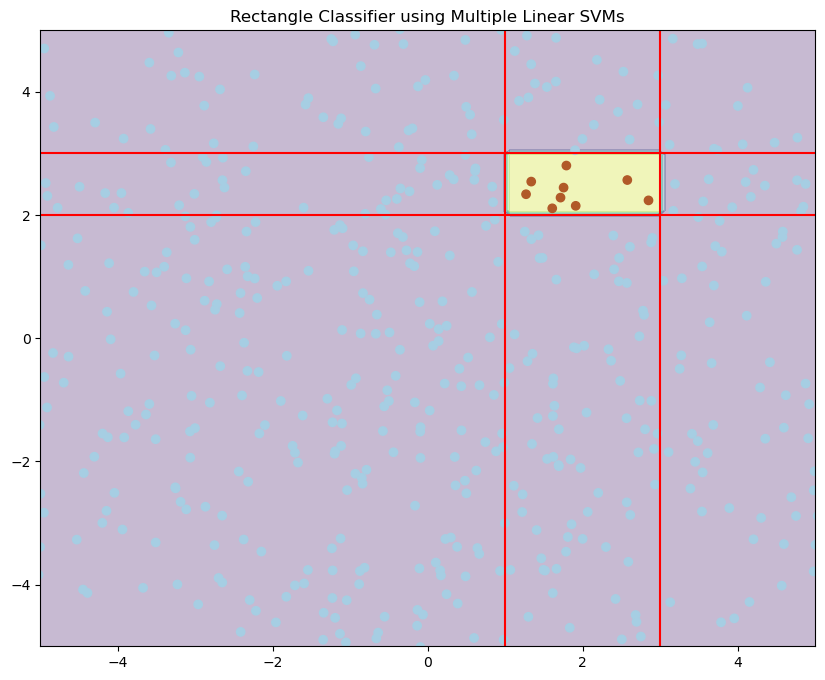

In [2]:
import numpy as np
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt

# Define rectangle bounds
a, b = 1, 3  # x-axis bounds
c, d = 2, 3  # y-axis bounds

# Create synthetic data
np.random.seed(42)
X = np.random.randn(1000, 2) * 5

# Label points: 1 if inside rectangle, 0 if outside
y = np.zeros(len(X))
mask = (X[:, 0] >= a) & (X[:, 0] <= b) & (X[:, 1] >= c) & (X[:, 1] <= d)
y[mask] = 1

# Train four separate SVMs for each boundary
# SVM 1: x₁ ≥ a
svm1 = LinearSVC(C=100)
svm1.fit(X[:, 0].reshape(-1, 1), (X[:, 0] >= a).astype(int))

# SVM 2: x₁ ≤ b
svm2 = LinearSVC(C=100)
svm2.fit(X[:, 0].reshape(-1, 1), (X[:, 0] <= b).astype(int))

# SVM 3: x₂ ≥ c
svm3 = LinearSVC(C=100)
svm3.fit(X[:, 1].reshape(-1, 1), (X[:, 1] >= c).astype(int))

# SVM 4: x₂ ≤ d
svm4 = LinearSVC(C=100)
svm4.fit(X[:, 1].reshape(-1, 1), (X[:, 1] <= d).astype(int))

# Combine predictions: point is in rectangle if all SVMs predict 1
def combined_predict(X):
    pred1 = svm1.predict(X[:, 0].reshape(-1, 1))
    pred2 = svm2.predict(X[:, 0].reshape(-1, 1))
    pred3 = svm3.predict(X[:, 1].reshape(-1, 1))
    pred4 = svm4.predict(X[:, 1].reshape(-1, 1))
    return (pred1 & pred2 & pred3 & pred4).astype(int)

# Visualize the results
xx, yy = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = combined_predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)
plt.axvline(x=a, color='r', linestyle='-')
plt.axvline(x=b, color='r', linestyle='-')
plt.axhline(y=c, color='r', linestyle='-')
plt.axhline(y=d, color='r', linestyle='-')
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.title('Rectangle Classifier using Multiple Linear SVMs')
plt.show()

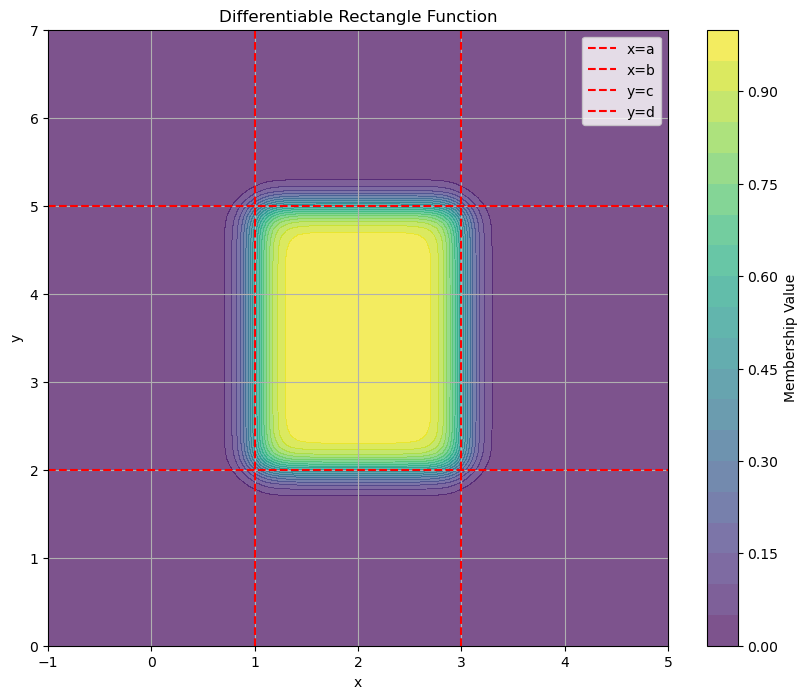

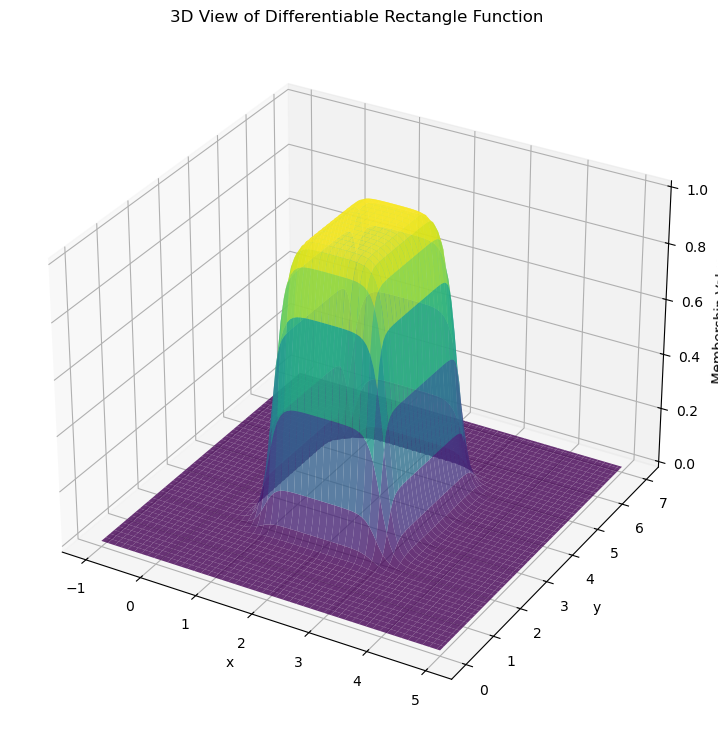

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Rectangle bounds
a, b = 1, 3  # x-axis bounds
c, d = 2, 5  # y-axis bounds

# Steepness parameter (higher = sharper transition)
k = 10

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Differentiable rectangle membership function
def diff_rectangle(x, y):
    # For each boundary, create a sigmoid that transitions from 0 to 1
    # For lower bounds, we want values above the bound to be close to 1
    bound1 = sigmoid(k * (x - a))  # x ≥ a
    # For upper bounds, we want values below the bound to be close to 1
    bound2 = sigmoid(k * (b - x))  # x ≤ b
    bound3 = sigmoid(k * (y - c))  # y ≥ c
    bound4 = sigmoid(k * (d - y))  # y ≤ d
    
    # Combine with multiplication (differentiable AND)
    return bound1 * bound2 * bound3 * bound4

# Create a grid for visualization
x = np.linspace(-1, 5, 100)
y = np.linspace(0, 7, 100)
X, Y = np.meshgrid(x, y)
Z = diff_rectangle(X, Y)

# 2D visualization
plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Z, 20, cmap='viridis', alpha=0.7)
plt.colorbar(label='Membership Value')
plt.axvline(x=a, color='r', linestyle='--', label='x=a')
plt.axvline(x=b, color='r', linestyle='--', label='x=b')
plt.axhline(y=c, color='r', linestyle='--', label='y=c')
plt.axhline(y=d, color='r', linestyle='--', label='y=d')
plt.grid(True)
plt.legend()
plt.title('Differentiable Rectangle Function')
plt.xlabel('x')
plt.ylabel('y')

# 3D visualization
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Membership Value')
ax.set_title('3D View of Differentiable Rectangle Function')
plt.show()

In [12]:
diff_rectangle(2,3)

0.9998638105158257

In [6]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Create rectangle parameters as learnable tensors
# Initialize with our exact values
a = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
c = torch.tensor(2.0, requires_grad=True)
d = torch.tensor(5.0, requires_grad=True)

# Steepness parameter (can also be made differentiable if needed)
k = torch.tensor(10.0, requires_grad=True)

def differentiable_rectangle(x, y, a, b, c, d, k):
    """
    Differentiable rectangle membership function with differentiable parameters.
    
    Args:
        x: PyTorch tensor for x-coordinates
        y: PyTorch tensor for y-coordinates
        a, b, c, d: Rectangle boundary parameters (PyTorch tensors)
        k: Steepness parameter (PyTorch tensor)
        
    Returns:
        PyTorch tensor containing membership values
    """
    # For each boundary, create a sigmoid that transitions from 0 to 1
    bound1 = torch.sigmoid(k * (x - a))  # x ≥ a
    bound2 = torch.sigmoid(k * (b - x))  # x ≤ b
    bound3 = torch.sigmoid(k * (y - c))  # y ≥ c
    bound4 = torch.sigmoid(k * (d - y))  # y ≤ d
    
    # Combine with multiplication (differentiable AND)
    return bound1 * bound2 * bound3 * bound4

# Example of taking gradients with respect to the parameters
def parameter_gradient_example():
    # Create a sample point inside the rectangle
    x = torch.tensor(2.0, requires_grad=True)
    y = torch.tensor(3.0, requires_grad=True)
    
    # Get membership value
    membership = differentiable_rectangle(x, y, a, b, c, d, k)
    
    # Compute gradients
    membership.backward()
    
    print("Gradients with respect to parameters:")
    print(f"∂f/∂a: {a.grad.item()}")
    print(f"∂f/∂b: {b.grad.item()}")
    print(f"∂f/∂c: {c.grad.item()}")
    print(f"∂f/∂d: {d.grad.item()}")
    print(f"∂f/∂k: {k.grad.item()}")
    print(f"∂f/∂x: {x.grad.item()}")
    print(f"∂f/∂y: {y.grad.item()}")
    
    # Reset gradients for next computation
    a.grad.zero_()
    b.grad.zero_()
    c.grad.zero_()
    d.grad.zero_()
    k.grad.zero_()
    
    return membership.item()

# This function can be used in an optimization loop
def optimize_rectangle_params(target_points, non_target_points, learning_rate=0.01, iterations=100):
    """
    Optimizes rectangle parameters to include target points and exclude non-target points.
    
    Args:
        target_points: Tensor of shape (n, 2) containing points that should be inside
        non_target_points: Tensor of shape (m, 2) containing points that should be outside
        learning_rate: Learning rate for gradient descent
        iterations: Number of optimization iterations
    """
    # Create optimizer for rectangle parameters
    optimizer = torch.optim.Adam([a, b, c, d, k], lr=learning_rate)
    
    for i in range(iterations):
        # Zero gradients
        optimizer.zero_grad()
        
        # Calculate membership for target points (should be high)
        target_membership = differentiable_rectangle(
            target_points[:, 0], target_points[:, 1], a, b, c, d, k
        ).mean()
        
        # Calculate membership for non-target points (should be low)
        non_target_membership = differentiable_rectangle(
            non_target_points[:, 0], non_target_points[:, 1], a, b, c, d, k
        ).mean()
        
        # Loss: maximize target membership, minimize non-target membership
        loss = -target_membership + non_target_membership
        
        # Backward pass
        loss.backward()
        
        # Update parameters
        optimizer.step()
        
        if i % 10 == 0:
            print(f"Iteration {i}: a={a.item():.2f}, b={b.item():.2f}, "
                  f"c={c.item():.2f}, d={d.item():.2f}, k={k.item():.2f}, "
                  f"Loss={loss.item():.4f}")
    
    print("Final rectangle parameters:")
    print(f"a={a.item():.2f}, b={b.item():.2f}, c={c.item():.2f}, d={d.item():.2f}, k={k.item():.2f}")

# Visualization function with differentiable parameters
def visualize_rectangle_with_params():
    # Create a grid for visualization
    x = torch.linspace(-1, 5, 100)
    y = torch.linspace(0, 7, 100)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    
    # Calculate membership values (detach parameters to avoid tracking computation)
    Z = differentiable_rectangle(
        X, Y, a.detach(), b.detach(), c.detach(), d.detach(), k.detach()
    )
    
    # Convert to numpy for plotting
    X_np = X.numpy()
    Y_np = Y.numpy()
    Z_np = Z.numpy()
    
    # 2D visualization
    plt.figure(figsize=(10, 8))
    plt.contourf(X_np, Y_np, Z_np, 20, cmap='viridis', alpha=0.7)
    plt.colorbar(label='Membership Value')
    plt.axvline(x=a.item(), color='r', linestyle='--', label=f'x={a.item():.2f}')
    plt.axvline(x=b.item(), color='r', linestyle='--', label=f'x={b.item():.2f}')
    plt.axhline(y=c.item(), color='r', linestyle='--', label=f'y={c.item():.2f}')
    plt.axhline(y=d.item(), color='r', linestyle='--', label=f'y={d.item():.2f}')
    plt.grid(True)
    plt.legend()
    plt.title(f'Differentiable Rectangle (k={k.item():.2f})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

=== Differentiable Rectangle in PyTorch ===
Current parameters: a=1.0, b=3.0, c=2.0, d=5.0, k=10.0

=== Membership Values for Test Points ===
Point 1: (2.0, 3.0) - Inside - Membership: 0.999864
Point 2: (0.0, 3.0) - Outside - Membership: 0.000045
Point 3: (4.0, 3.0) - Outside - Membership: 0.000045
Point 4: (2.0, 1.0) - Outside - Membership: 0.000045
Point 5: (2.0, 6.0) - Outside - Membership: 0.000045
Point 6: (1.1, 2.1) - Inside - Membership: 0.534447
Point 7: (2.9, 4.9) - Inside - Membership: 0.534446
Point 8: (2.0, 4.9) - Inside - Membership: 0.730992

=== Gradients with respect to parameters ===
Point evaluated: (2.0, 3.0)
Membership value: 0.999864
∂f/∂a: -0.000454
∂f/∂b: 0.000454
∂f/∂c: -0.000454
∂f/∂d: 0.000000
∂f/∂k: 0.000136
∂f/∂x: 0.000000
∂f/∂y: 0.000454

=== Rectangle Parameter Optimization Demo ===
Starting parameters: a=0.0, b=2.0, c=1.0, d=3.0, k=5.0
Target: Optimize rectangle to include target points and exclude non-target points

Optimization progress:
Iteration 0: a=

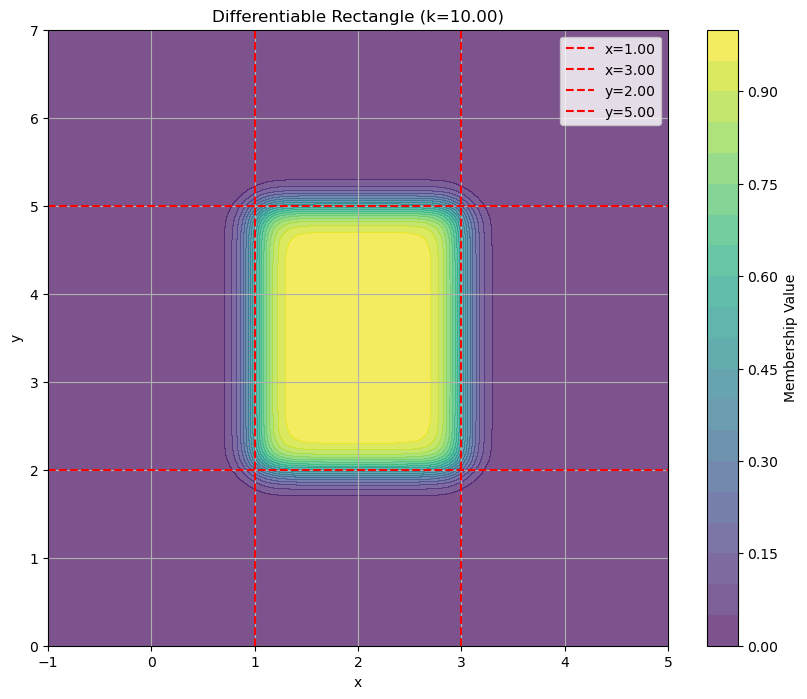

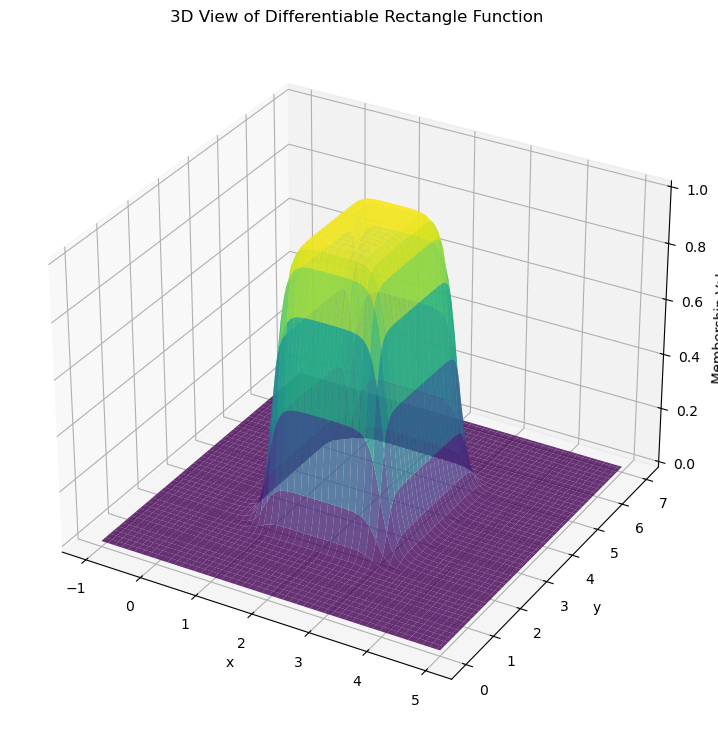

In [7]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Create rectangle parameters as learnable tensors
# Initialize with our exact values
a = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
c = torch.tensor(2.0, requires_grad=True)
d = torch.tensor(5.0, requires_grad=True)

# Steepness parameter (can also be made differentiable if needed)
k = torch.tensor(10.0, requires_grad=True)

def differentiable_rectangle(x, y, a, b, c, d, k):
    """
    Differentiable rectangle membership function with differentiable parameters.
    
    Args:
        x: PyTorch tensor for x-coordinates
        y: PyTorch tensor for y-coordinates
        a, b, c, d: Rectangle boundary parameters (PyTorch tensors)
        k: Steepness parameter (PyTorch tensor)
        
    Returns:
        PyTorch tensor containing membership values
    """
    # For each boundary, create a sigmoid that transitions from 0 to 1
    bound1 = torch.sigmoid(k * (x - a))  # x ≥ a
    bound2 = torch.sigmoid(k * (b - x))  # x ≤ b
    bound3 = torch.sigmoid(k * (y - c))  # y ≥ c
    bound4 = torch.sigmoid(k * (d - y))  # y ≤ d
    
    # Combine with multiplication (differentiable AND)
    return bound1 * bound2 * bound3 * bound4

def parameter_gradient_example():
    """Calculate gradients with respect to rectangle parameters for a single point."""
    # Create a sample point inside the rectangle
    x = torch.tensor(2.0, requires_grad=True)
    y = torch.tensor(3.0, requires_grad=True)
    
    # Get membership value
    membership = differentiable_rectangle(x, y, a, b, c, d, k)
    
    # Compute gradients
    membership.backward()
    
    print("\n=== Gradients with respect to parameters ===")
    print(f"Point evaluated: (2.0, 3.0)")
    print(f"Membership value: {membership.item():.6f}")
    print(f"∂f/∂a: {a.grad.item():.6f}")
    print(f"∂f/∂b: {b.grad.item():.6f}")
    print(f"∂f/∂c: {c.grad.item():.6f}")
    print(f"∂f/∂d: {d.grad.item():.6f}")
    print(f"∂f/∂k: {k.grad.item():.6f}")
    print(f"∂f/∂x: {x.grad.item():.6f}")
    print(f"∂f/∂y: {y.grad.item():.6f}")
    
    # Reset gradients for next computation
    a.grad.zero_()
    b.grad.zero_()
    c.grad.zero_()
    d.grad.zero_()
    k.grad.zero_()

def visualize_rectangle():
    """Visualize the differentiable rectangle in 2D and 3D."""
    # Create a grid for visualization
    x = torch.linspace(-1, 5, 100)
    y = torch.linspace(0, 7, 100)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    
    # Calculate membership values (detach parameters to avoid tracking computation)
    Z = differentiable_rectangle(
        X, Y, a.detach(), b.detach(), c.detach(), d.detach(), k.detach()
    )
    
    # Convert to numpy for plotting
    X_np = X.numpy()
    Y_np = Y.numpy()
    Z_np = Z.numpy()
    
    # 2D visualization
    plt.figure(figsize=(10, 8))
    plt.contourf(X_np, Y_np, Z_np, 20, cmap='viridis', alpha=0.7)
    plt.colorbar(label='Membership Value')
    plt.axvline(x=a.item(), color='r', linestyle='--', label=f'x={a.item():.2f}')
    plt.axvline(x=b.item(), color='r', linestyle='--', label=f'x={b.item():.2f}')
    plt.axhline(y=c.item(), color='r', linestyle='--', label=f'y={c.item():.2f}')
    plt.axhline(y=d.item(), color='r', linestyle='--', label=f'y={d.item():.2f}')
    plt.grid(True)
    plt.legend()
    plt.title(f'Differentiable Rectangle (k={k.item():.2f})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()
    
    # 3D visualization
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X_np, Y_np, Z_np, cmap='viridis', alpha=0.8)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('Membership Value')
    ax.set_title('3D View of Differentiable Rectangle Function')
    plt.show()

def check_specific_points():
    """Check membership values for specific points."""
    # Test points inside and outside the rectangle
    test_points = [
        (2.0, 3.0),  # Inside
        (0.0, 3.0),  # Outside (left)
        (4.0, 3.0),  # Outside (right)
        (2.0, 1.0),  # Outside (bottom)
        (2.0, 6.0),  # Outside (top)
        (1.1, 2.1),  # Just inside corner
        (2.9, 4.9),  # Just inside opposite corner
        (2.0, 4.9)   # Near top boundary
    ]
    
    print("\n=== Membership Values for Test Points ===")
    for i, (x_val, y_val) in enumerate(test_points):
        x_tensor = torch.tensor(x_val)
        y_tensor = torch.tensor(y_val)
        membership = differentiable_rectangle(
            x_tensor, y_tensor, a, b, c, d, k
        ).item()
        
        point_type = "Inside" if (a.item() <= x_val <= b.item() and c.item() <= y_val <= d.item()) else "Outside"
        print(f"Point {i+1}: ({x_val}, {y_val}) - {point_type} - Membership: {membership:.6f}")

def demonstrate_optimization():
    """Demonstrate optimizing rectangle parameters to fit a set of points."""
    # Create some points that should be inside the rectangle
    target_points = torch.tensor([
        [1.5, 3.0],
        [2.0, 3.5],
        [2.5, 4.0],
        [1.7, 2.7]
    ], dtype=torch.float32)
    
    # Create some points that should be outside the rectangle
    non_target_points = torch.tensor([
        [0.0, 0.0],
        [0.5, 6.0],
        [4.0, 3.0],
        [2.0, 1.0]
    ], dtype=torch.float32)
    
    # Temporarily create new parameters for this demo to avoid modifying the main ones
    a_opt = torch.tensor(0.0, requires_grad=True)  # Starting with very different values
    b_opt = torch.tensor(2.0, requires_grad=True)
    c_opt = torch.tensor(1.0, requires_grad=True)
    d_opt = torch.tensor(3.0, requires_grad=True)
    k_opt = torch.tensor(5.0, requires_grad=True)
    
    # Create optimizer
    optimizer = torch.optim.Adam([a_opt, b_opt, c_opt, d_opt, k_opt], lr=0.05)
    
    print("\n=== Rectangle Parameter Optimization Demo ===")
    print("Starting parameters: a=0.0, b=2.0, c=1.0, d=3.0, k=5.0")
    print("Target: Optimize rectangle to include target points and exclude non-target points")
    print("\nOptimization progress:")
    
    # Optimization loop
    for i in range(50):
        # Zero gradients
        optimizer.zero_grad()
        
        # Calculate membership for target points (should be high)
        target_membership = differentiable_rectangle(
            target_points[:, 0], target_points[:, 1], 
            a_opt, b_opt, c_opt, d_opt, k_opt
        ).mean()
        
        # Calculate membership for non-target points (should be low)
        non_target_membership = differentiable_rectangle(
            non_target_points[:, 0], non_target_points[:, 1], 
            a_opt, b_opt, c_opt, d_opt, k_opt
        ).mean()
        
        # Loss: maximize target membership, minimize non-target membership
        loss = -target_membership + non_target_membership
        
        # Backward pass
        loss.backward()
        
        # Update parameters
        optimizer.step()
        
        if i % 10 == 0:
            print(f"Iteration {i}: a={a_opt.item():.2f}, b={b_opt.item():.2f}, "
                  f"c={c_opt.item():.2f}, d={d_opt.item():.2f}, k={k_opt.item():.2f}, "
                  f"Loss={loss.item():.4f}")
    
    print("\nFinal optimized parameters:")
    print(f"a={a_opt.item():.2f}, b={b_opt.item():.2f}, c={c_opt.item():.2f}, d={d_opt.item():.2f}, k={k_opt.item():.2f}")
    
    # Evaluate final membership values
    target_membership = differentiable_rectangle(
        target_points[:, 0], target_points[:, 1], 
        a_opt, b_opt, c_opt, d_opt, k_opt
    )
    
    non_target_membership = differentiable_rectangle(
        non_target_points[:, 0], non_target_points[:, 1], 
        a_opt, b_opt, c_opt, d_opt, k_opt
    )
    
    print("\nFinal membership values:")
    print("Target points:")
    for i, (point, membership) in enumerate(zip(target_points, target_membership)):
        print(f"  Point {i+1}: ({point[0]:.2f}, {point[1]:.2f}) - Membership: {membership.item():.4f}")
    
    print("\nNon-target points:")
    for i, (point, membership) in enumerate(zip(non_target_points, non_target_membership)):
        print(f"  Point {i+1}: ({point[0]:.2f}, {point[1]:.2f}) - Membership: {membership.item():.4f}")

def main():
    """Main function to run all demonstrations."""
    print("=== Differentiable Rectangle in PyTorch ===")
    print("Current parameters: a=1.0, b=3.0, c=2.0, d=5.0, k=10.0")
    
    # Check membership values for specific points
    check_specific_points()
    
    # Compute gradients
    parameter_gradient_example()
    
    # Demonstrate optimization
    demonstrate_optimization()
    
    # Visualize the rectangle
    visualize_rectangle()

if __name__ == "__main__":
    main()
    